# Real-Time Speech Emotion Recognition — Optimized for RTX 3050 Ti (4GB)
### ALL 3 Datasets: RAVDESS + CREMA-D + IEMOCAP

| Component | Spec |
|-----------|------|
| GPU | RTX 3050 Ti Laptop, 4 GB VRAM |
| RAM | 16 GB DDR4 |
| CPU | i5-12450H, 12 threads |

```
data/
├── ravdess/
│   └── Actor_01/03-01-01-01-01-01-01.wav
├── crema-d/
│   └── AudioWAV/1001_DFA_ANG_XX.wav
└── iemocap/
    ├── Session1/sentences/wav/... + dialog/EmoEvaluation/...
    └── Session2/ ... Session5/
```

In [14]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip(
    'torch', 'torchaudio',
    'transformers', 'accelerate',
    'openai-whisper', 'openai',
    'scikit-learn', 'seaborn',
    'tqdm', 'pandas', 'matplotlib',
    'onnx', 'onnxruntime'
)

try:
    pip('sounddevice')
except Exception:
    print('sounddevice install failed — real-time mic cell will be skipped')

print('All packages installed.')

All packages installed.


In [38]:
import os, re, random, json, time, warnings, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 16,
    'epochs'      : 30,
    'lr'          : 1e-4,
    'dropout'     : 0.3,
    'num_workers' : 0,
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,
}

HUBERT_CFG = {
    **CFG,
    'lr'         : 1e-5,
    'batch_size' : 2,
    'epochs'     : 30,
    'num_workers': 0,
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if CFG['device'] == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])
    torch.backends.cudnn.benchmark = True

print(f"Device    : {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch   : {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")

Device    : cuda
GPU       : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM      : 4.3 GB
PyTorch   : 2.5.1+cu121
torchaudio: 2.5.1+cu121


Parsing RAVDESS...
  RAVDESS: 1248 samples, 24 speakers
Parsing CREMA-D...
  CREMA-D: 7442 samples, 91 speakers
Parsing IEMOCAP from CSV...
IEMOCAP CSV: 9949 samples from 1 speakers
label
angry      4231
happy      2735
neutral    1741
sad        1097
fearful     104
disgust      41
Name: count, dtype: int64

Total samples : 18639
Total speakers: 116
dataset
iemocap    9949
cremad     7442
ravdess    1248
label
angry      5694
happy      4198
neutral    3116
sad        2560
fearful    1567
disgust    1504


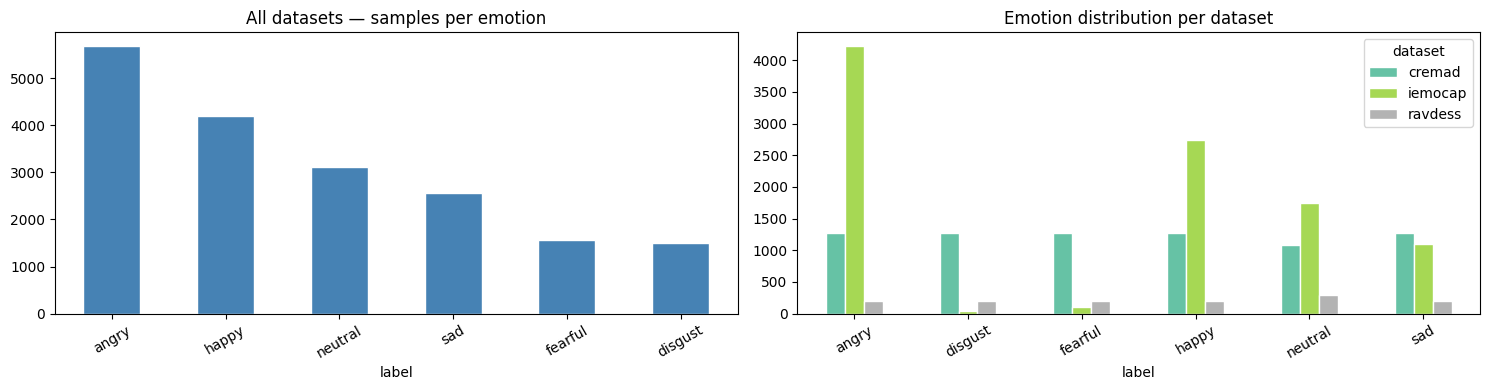

In [41]:
UNIFIED_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

RAVDESS_MAP = {
    '01': 'neutral',
    '02': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': None,
}

def parse_ravdess(root='data/ravdess'):
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) != 7:
            continue
        label    = RAVDESS_MAP.get(parts[2])
        actor_id = int(parts[6])
        if label:
            records.append({'path': str(wav), 'label': label,
                            'speaker_id': f'R{actor_id:03d}', 'dataset': 'ravdess'})
    return pd.DataFrame(records)

CREMAD_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad',
}

def parse_cremad(audio_dir='data/crema-d/AudioWAV'):
    records = []
    for wav in Path(audio_dir).glob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3:
            continue
        label = CREMAD_MAP.get(parts[2])
        if label:
            records.append({'path': str(wav), 'label': label,
                            'speaker_id': f'C{parts[0]}', 'dataset': 'cremad'})
    return pd.DataFrame(records)

IEMOCAP_MAP = {
    'neu': 'neutral', 'hap': 'happy',  'exc': 'happy',
    'sad': 'sad',     'ang': 'angry',  'fru': 'angry',
    'fea': 'fearful', 'dis': 'disgust','sur': None,
    'xxx': None,      'oth': None,
}

IEMOCAP_CSV_MAP = {
    'Frustration': 'angry',
    'Anger'      : 'angry',
    'Excited'    : 'happy',
    'Neutral'    : 'neutral',
    'Sadness'    : 'sad',
    'Happiness'  : 'happy',
    'Fear'       : 'fearful',
    'Disgust'    : 'disgust',
    'Surprise'   : None,   # dropped
}

def parse_iemocap_csv(csv_path='training_data.csv', 
                       local_root='data/iemocap'):
    df_csv = pd.read_csv(csv_path)
    records = []
    for _, row in df_csv.iterrows():
        label = IEMOCAP_CSV_MAP.get(row['emotion'])
        if not label:
            continue  # drop Surprise

        # Fix path: replace kaggle path with your local path
        # /kaggle/working/audio_files/Session5/sentences/wav/...
        # → data/iemocap/Session5/sentences/wav/...
        old_path  = row['audio_path']
        rel_path  = old_path.split('audio_files/')[-1]  # Session5/sentences/...
        new_path  = str(Path(local_root) / rel_path)

        # Extract speaker_id from file_id e.g. Ses05M_script → I5M
        fid        = row['file_id']          # Ses05M_script03_2_M016
        session_num= fid[3]                  # '5'
        gender     = 'M' if '_M' in fid[-4:] else 'F'
        speaker_id = f'I{session_num}{gender}'

        records.append({
            'path'      : new_path,
            'label'     : label,
            'speaker_id': speaker_id,
            'dataset'   : 'iemocap'
        })

    df = pd.DataFrame(records)
    print(f'IEMOCAP CSV: {len(df)} samples from '
          f'{df["speaker_id"].nunique()} speakers')
    return df

print('Parsing RAVDESS...')
df_rav = parse_ravdess('data/ravdess')
print(f'  RAVDESS: {len(df_rav)} samples, {df_rav["speaker_id"].nunique()} speakers')

print('Parsing CREMA-D...')
df_cre = parse_cremad('data/crema-d/AudioWAV')
print(f'  CREMA-D: {len(df_cre)} samples, {df_cre["speaker_id"].nunique()} speakers')

print('Parsing IEMOCAP from CSV...')
df_iem = parse_iemocap_csv(
    csv_path='data/iemocap/training_data.csv',   # put CSV in your project folder
    local_root='data/iemocap'
)
print(df_iem['label'].value_counts())

df_all = pd.concat([df_rav, df_cre, df_iem], ignore_index=True)
le     = LabelEncoder().fit(UNIFIED_EMOTIONS)
df_all['label_id'] = le.transform(df_all['label'])

print(f'\nTotal samples : {len(df_all)}')
print(f'Total speakers: {df_all["speaker_id"].nunique()}')
print(df_all['dataset'].value_counts().to_string())
print(df_all['label'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df_all['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('All datasets — samples per emotion')
axes[0].tick_params(axis='x', rotation=30)
pivot = df_all.groupby(['label', 'dataset']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Emotion distribution per dataset')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
def speaker_independent_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    speakers = df['speaker_id'].unique().tolist()
    random.seed(seed)
    random.shuffle(speakers)
    n         = len(speakers)
    n_test    = int(n * test_ratio)
    n_val     = int(n * val_ratio)
    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test : n_test + n_val])
    train_spk = set(speakers[n_test + n_val:])
    df_train  = df[df['speaker_id'].isin(train_spk)].reset_index(drop=True)
    df_val    = df[df['speaker_id'].isin(val_spk)].reset_index(drop=True)
    df_test   = df[df['speaker_id'].isin(test_spk)].reset_index(drop=True)
    return df_train, df_val, df_test

df_train, df_val, df_test = speaker_independent_split(df_all)

print(f'Train: {len(df_train):,} samples | {df_train["speaker_id"].nunique()} speakers')
print(f'Val  : {len(df_val):,} samples | {df_val["speaker_id"].nunique()} speakers')
print(f'Test : {len(df_test):,} samples | {df_test["speaker_id"].nunique()} speakers')

assert not (set(df_train['speaker_id']) & set(df_test['speaker_id'])), 'TRAIN/TEST LEAKAGE!'
assert not (set(df_train['speaker_id']) & set(df_val['speaker_id'])),  'TRAIN/VAL LEAKAGE!'
assert not (set(df_val['speaker_id'])   & set(df_test['speaker_id'])), 'VAL/TEST LEAKAGE!'
print('No speaker leakage confirmed.')

for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{split_name}: {split_df["dataset"].value_counts().to_dict()}')

Train: 6,088 samples | 81 speakers
Val  : 1,268 samples | 17 speakers
Test : 1,334 samples | 17 speakers
No speaker leakage confirmed.
Train: {'cremad': 5152, 'ravdess': 936}
Val: {'cremad': 1060, 'ravdess': 208}
Test: {'cremad': 1230, 'ravdess': 104}


RAVDESS   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
CREMA-D   : mfcc=torch.Size([1, 120, 201]) | lmel=torch.Size([1, 128, 201]) | wav=torch.Size([1, 32000])
IEMOCAP: EMPTY — check path


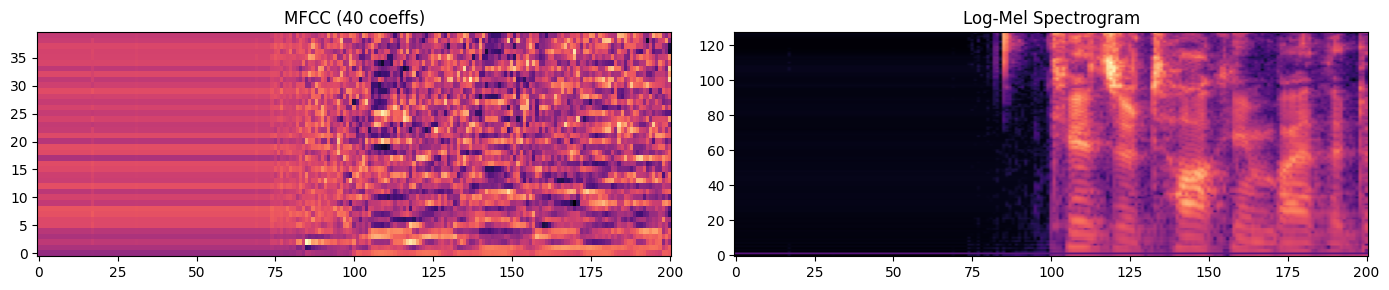

In [18]:
class AudioPreprocessor:
    def __init__(self, cfg=CFG):
        self.sr        = cfg['sr']
        self.n_samples = int(cfg['sr'] * cfg['clip_sec'])
        self.mfcc_tfm  = T.MFCC(
            sample_rate=cfg['sr'], n_mfcc=cfg['n_mfcc'],
            melkwargs={'n_fft': cfg['n_fft'], 'hop_length': cfg['hop_length'],
                       'win_length': cfg['win_length'], 'n_mels': cfg['n_mels'],
                       'f_min': cfg['f_min'], 'f_max': cfg['f_max']}
        )
        self.mel_tfm   = T.MelSpectrogram(
            sample_rate=cfg['sr'], n_fft=cfg['n_fft'], hop_length=cfg['hop_length'],
            win_length=cfg['win_length'], n_mels=cfg['n_mels'],
            f_min=cfg['f_min'], f_max=cfg['f_max']
        )
        self.amp_to_db = T.AmplitudeToDB(top_db=80)
        self.delta     = T.ComputeDeltas()

    def load(self, path):
        wav, sr = torchaudio.load(str(path))
        if wav.shape[0] > 1:
            wav = wav.mean(0, keepdim=True)
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        return wav

    def pad_or_trim(self, wav):
        n = wav.shape[-1]
        if n >= self.n_samples:
            return wav[..., :self.n_samples]
        pad = self.n_samples - n
        return F.pad(wav, (pad // 2, pad - pad // 2))

    @staticmethod
    def normalize(t):
        mean = t.mean(dim=-1, keepdim=True)
        std  = t.std(dim=-1, keepdim=True).clamp(min=1e-6)
        return (t - mean) / std

    def __call__(self, path):
        wav    = self.load(path)
        wav    = self.pad_or_trim(wav)
        mfcc   = self.mfcc_tfm(wav)
        d1     = self.delta(mfcc)
        d2     = self.delta(d1)
        mfcc_f = torch.cat([mfcc, d1, d2], dim=1)
        mel    = self.mel_tfm(wav)
        lmel   = self.amp_to_db(mel)
        wav_norm = wav / wav.abs().max().clamp(min=1e-6)
        return self.normalize(mfcc_f), self.normalize(lmel), wav_norm


preprocessor = AudioPreprocessor(CFG)

for ds_name, ds_df in [('RAVDESS', df_rav), ('CREMA-D', df_cre), ('IEMOCAP', df_iem)]:
    if len(ds_df) == 0:
        print(f'{ds_name}: EMPTY — check path')
        continue
    p = ds_df['path'].iloc[0]
    mfcc, lmel, wav = preprocessor(p)
    print(f'{ds_name:10s}: mfcc={mfcc.shape} | lmel={lmel.shape} | wav={wav.shape}')

sample_path = df_train['path'].iloc[0]
mfcc, lmel, wav = preprocessor(sample_path)
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(mfcc[0, :40].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('MFCC (40 coeffs)')
axes[1].imshow(lmel[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [21]:
CACHE_FILE = 'features_cache.pkl'

def precompute_features(df, preprocessor, cache_file=CACHE_FILE):
    if Path(cache_file).exists():
        print(f'Loading cached features from {cache_file}...')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    print(f'Pre-computing features for {len(df)} samples — runs ONCE then saved to disk...')
    cache = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Caching features'):
        try:
            mfcc, lmel, wav = preprocessor(row['path'])
            cache[row['path']] = (mfcc, lmel, wav)
        except Exception as e:
            print(f'  Skipping {row["path"]}: {e}')
    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    print(f'Saved to {cache_file} — will be reused in all future runs')
    return cache

feature_cache = precompute_features(df_all, preprocessor)
print(f'Cache size: {len(feature_cache)} samples')

Pre-computing features for 8690 samples — runs ONCE then saved to disk...


Caching features: 100%|██████████| 8690/8690 [02:00<00:00, 72.36it/s]


Saved to features_cache.pkl — will be reused in all future runs
Cache size: 8690 samples


In [22]:
class SpeechAugment:
    def __init__(self, sr=16_000, p=0.5):
        self.sr = sr
        self.p  = p

    def add_gaussian_noise(self, wav, snr_db_range=(10, 30)):
        snr       = random.uniform(*snr_db_range)
        sig_pow   = wav.norm(p=2) ** 2 / wav.numel()
        noise_pow = sig_pow / (10 ** (snr / 10))
        return (wav + torch.randn_like(wav) * noise_pow.sqrt()).clamp(-1.0, 1.0)

    def add_pink_noise(self, wav, noise_level=(0.002, 0.015)):
        f     = torch.fft.rfftfreq(wav.shape[-1]).clamp(min=1e-6)
        pink  = (1.0 / f.sqrt()) * torch.randn(len(f), dtype=torch.complex64)
        noise = torch.fft.irfft(pink, n=wav.shape[-1]).unsqueeze(0)
        noise = noise / noise.abs().max().clamp(min=1e-6)
        alpha = random.uniform(*noise_level)
        return (wav + alpha * noise).clamp(-1.0, 1.0)

    def volume_perturb(self, wav, db_range=(-6, 6)):
        db = random.uniform(*db_range)
        return (wav * (10 ** (db / 20))).clamp(-1.0, 1.0)

    def time_mask(self, spec, max_pct=0.20):
        T = spec.shape[-1]
        w = max(1, int(T * max_pct * random.random()))
        s = random.randint(0, max(0, T - w - 1))
        spec = spec.clone()
        spec[..., s:s + w] = 0.0
        return spec

    def freq_mask(self, spec, max_pct=0.15):
        Fd = spec.shape[-2]
        w  = max(1, int(Fd * max_pct * random.random()))
        s  = random.randint(0, max(0, Fd - w - 1))
        spec = spec.clone()
        spec[:, s:s + w, :] = 0.0
        return spec

    def time_stretch_spec(self, spec, rate_range=(0.85, 1.15)):
        rate  = random.uniform(*rate_range)
        T     = spec.shape[-1]
        new_T = max(1, int(T / rate))
        out   = F.interpolate(
            spec.unsqueeze(0).float(),
            size=(spec.shape[-2], new_T),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        return out[..., :T] if new_T >= T else F.pad(out, (0, T - new_T))

    def __call__(self, wav, spec):
        if random.random() < self.p:
            fn  = random.choice([self.add_gaussian_noise,
                                  self.add_pink_noise,
                                  self.volume_perturb])
            wav = fn(wav)
        if random.random() < self.p:
            spec = self.time_mask(spec)
        if random.random() < self.p:
            spec = self.freq_mask(spec)
        if random.random() < self.p:
            spec = self.time_stretch_spec(spec)
        return wav, spec

augmenter = SpeechAugment(sr=CFG['sr'], p=0.5)
print('Augmenter ready.')

Augmenter ready.


In [23]:
class EmotionDataset(Dataset):
    def __init__(self, df, preprocessor, augmenter=None, augment=False, cache=None):
        self.df           = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmenter    = augmenter
        self.augment      = augment
        self.cache        = cache

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.cache and row['path'] in self.cache:
            mfcc, lmel, wav = self.cache[row['path']]
        else:
            mfcc, lmel, wav = self.preprocessor(row['path'])

        if self.augment and self.augmenter:
            wav, lmel = self.augmenter(wav, lmel)
            m    = self.preprocessor.mfcc_tfm(wav)
            d1   = self.preprocessor.delta(m)
            d2   = self.preprocessor.delta(d1)
            mfcc = self.preprocessor.normalize(torch.cat([m, d1, d2], dim=1))
            lmel = self.preprocessor.normalize(lmel)

        return {
            'mfcc' : mfcc,
            'spec' : lmel,
            'wav'  : wav.squeeze(0),
            'label': torch.tensor(row['label_id'], dtype=torch.long),
        }


def make_weighted_sampler(df):
    counts  = Counter(df['label_id'].tolist())
    total   = len(df)
    w_class = {c: total / cnt for c, cnt in counts.items()}
    weights = [w_class[l] for l in df['label_id']]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


train_ds = EmotionDataset(df_train, preprocessor, augmenter, augment=True,  cache=feature_cache)
val_ds   = EmotionDataset(df_val,   preprocessor, augment=False, cache=feature_cache)
test_ds  = EmotionDataset(df_test,  preprocessor, augment=False, cache=feature_cache)

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    num_workers=0, pin_memory=(CFG['device'] == 'cuda')
)
val_loader = DataLoader(val_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
test_loader= DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

sample = next(iter(train_loader))
print(f"spec  : {sample['spec'].shape}")
print(f"mfcc  : {sample['mfcc'].shape}")
print(f"wav   : {sample['wav'].shape}")
print(f"label : {sample['label']}")

Train batches : 381
Val   batches : 80
Test  batches : 84
spec  : torch.Size([16, 1, 128, 201])
mfcc  : torch.Size([16, 1, 120, 201])
wav   : torch.Size([16, 32000])
label : tensor([3, 5, 4, 0, 1, 3, 5, 2, 5, 3, 1, 2, 3, 2, 3, 3])


In [24]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], dropout=CFG['dropout']):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.15),
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


class CNNLSTM(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'],
                 lstm_hidden=256, lstm_layers=2, dropout=CFG['dropout']):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),
        )
        self.rnn = nn.LSTM(
            input_size=128 * 16, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.attn_fc    = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat   = self.cnn(x)
        B, C, F_dim, T = feat.shape
        feat   = feat.permute(0, 3, 1, 2).reshape(B, T, C * F_dim)
        out, _ = self.rnn(feat)
        attn   = torch.softmax(self.attn_fc(out), dim=1)
        ctx    = (attn * out).sum(dim=1)
        return self.classifier(ctx)


class HuBERTEmotionClassifier(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], freeze_bottom=9, dropout=0.1):
        super().__init__()
        from transformers import HubertModel
        self.hubert = HubertModel.from_pretrained('facebook/hubert-base-ls960', use_safetensors=True)
        self.hubert.gradient_checkpointing_enable()
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < freeze_bottom:
                for p in layer.parameters():
                    p.requires_grad = False
        h               = self.hubert.config.hidden_size
        n_tuned         = len(self.hubert.encoder.layers) - freeze_bottom
        self.layer_weights = nn.Parameter(torch.ones(n_tuned) / n_tuned)
        self.n_tuned    = n_tuned
        self.proj       = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, wav, attention_mask=None):
        out     = self.hubert(wav, attention_mask=attention_mask, output_hidden_states=True)
        layers  = torch.stack(out.hidden_states[-self.n_tuned:], dim=1)
        weights = torch.softmax(self.layer_weights, dim=0)
        pooled  = (layers * weights[None,:,None,None]).sum(1).mean(1)
        return self.proj(pooled)


for name, model in [('BaselineCNN', BaselineCNN()), ('CNN+LSTM', CNNLSTM())]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:20s}: {trainable/1e6:.2f}M trainable / {total/1e6:.2f}M total params')

BaselineCNN         : 0.81M trainable / 0.81M total params
CNN+LSTM            : 6.59M trainable / 6.59M total params


In [25]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=CFG['num_classes']):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.ones(num_classes) / num_classes if alpha is None \
                     else torch.tensor(alpha, dtype=torch.float32)

    def forward(self, logits, targets):
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        lpt   = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha = self.alpha.to(logits.device).gather(0, targets)
        return (-alpha * (1 - pt) ** self.gamma * lpt).mean()


def run_epoch(model, loader, criterion, optimizer, scheduler,
              device, train=True, use_wav=False, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval ', leave=False):
            labels = batch['label'].to(device)
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(inp)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler:
                    scheduler.step()
            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


def train_model(model_class, model_kwargs, cfg=CFG,
                use_wav=False, model_name='model',
                t_loader=None, v_loader=None):
    t_loader  = t_loader or train_loader
    v_loader  = v_loader or val_loader
    device    = torch.device(cfg['device'])
    model     = model_class(**model_kwargs).to(device)
    criterion = FocalLoss(gamma=2.0, num_classes=cfg['num_classes'])
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=1e-4
    )
    scheduler = OneCycleLR(
        optimizer, max_lr=cfg['lr'],
        steps_per_epoch=len(t_loader),
        epochs=cfg['epochs'], pct_start=0.1
    )
    scaler  = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
    best_f1, patience, wait = 0.0, 10, 0
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Training {model_name} | {total_params/1e6:.2f}M params | '
          f'device={device} | epochs={cfg["epochs"]} | batch={cfg["batch_size"]}')
    for epoch in range(cfg['epochs']):
        t_loss, t_acc, t_f1, _, _ = run_epoch(
            model, t_loader, criterion, optimizer, scheduler,
            device, train=True, use_wav=use_wav, scaler=scaler
        )
        v_loss, v_acc, v_f1, _, _ = run_epoch(
            model, v_loader, criterion, None, None,
            device, train=False, use_wav=use_wav
        )
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)
        print(f'Ep {epoch+1:3d}/{cfg["epochs"]} | '
              f'T-Loss {t_loss:.4f} T-F1 {t_f1:.4f} | '
              f'V-Loss {v_loss:.4f} V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1} (best val F1 = {best_f1:.4f})')
                break
    model.load_state_dict(torch.load(f'best_{model_name}.pt', map_location=device))
    return model, history


def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax1.plot(ep, history['train_loss'], label='Train')
    ax1.plot(ep, history['val_loss'],   label='Val')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(ep, history['train_f1'], label='Train')
    ax2.plot(ep, history['val_f1'],   label='Val')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()

print('Training utilities ready.')

Training utilities ready.


Training cnn | 0.81M params | device=cuda | epochs=30 | batch=16


Ep   1/30 | T-Loss 0.1964 T-F1 0.2114 | V-Loss 0.1939 V-F1 0.2573 V-Acc 0.3249


Ep   2/30 | T-Loss 0.1750 T-F1 0.3279 | V-Loss 0.2447 V-F1 0.2577 V-Acc 0.3233


Ep   3/30 | T-Loss 0.1672 T-F1 0.3619 | V-Loss 0.2493 V-F1 0.2738 V-Acc 0.3304


Ep   4/30 | T-Loss 0.1650 T-F1 0.3482 | V-Loss 0.4132 V-F1 0.2230 V-Acc 0.2808


...

Ep  26/30 | T-Loss 0.1174 T-F1 0.5301 | V-Loss 0.4039 V-F1 0.3481 V-Acc 0.3801


Ep  27/30 | T-Loss 0.1187 T-F1 0.5248 | V-Loss 0.3967 V-F1 0.3636 V-Acc 0.3927


Ep  28/30 | T-Loss 0.1162 T-F1 0.5340 | V-Loss 0.3895 V-F1 0.3503 V-Acc 0.3833


Ep  29/30 | T-Loss 0.1157 T-F1 0.5333 | V-Loss 0.3906 V-F1 0.3617 V-Acc 0.3920


Ep  30/30 | T-Loss 0.1167 T-F1 0.5285 | V-Loss 0.3989 V-F1 0.3520 V-Acc 0.3841


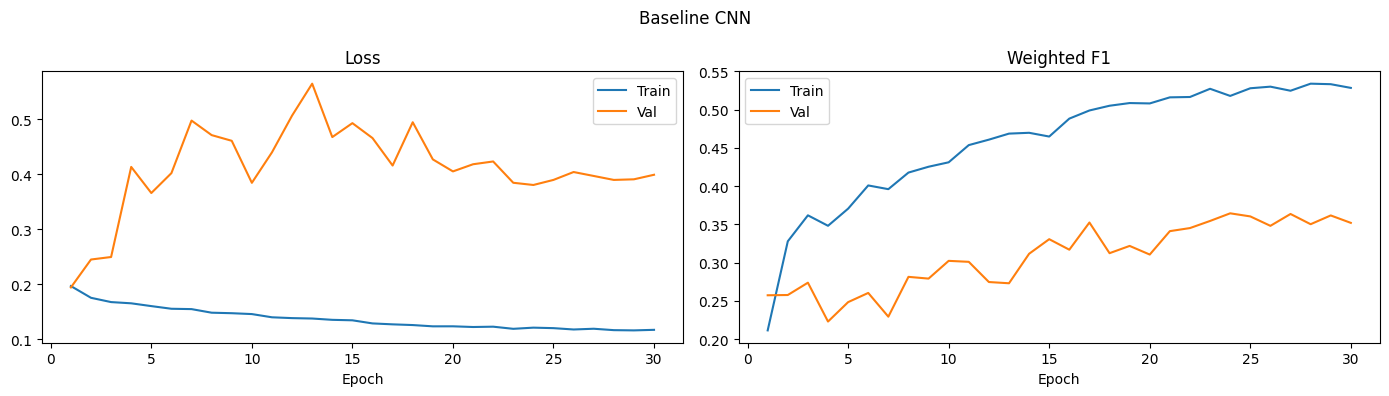

Best CNN val F1: 0.3645


In [26]:
cnn_model, cnn_history = train_model(
    BaselineCNN,
    {'num_classes': CFG['num_classes'], 'dropout': CFG['dropout']},
    cfg=CFG,
    model_name='cnn'
)
plot_history(cnn_history, 'Baseline CNN')
print(f'Best CNN val F1: {max(cnn_history["val_f1"]):.4f}')

Training cnnlstm | 6.59M params | device=cuda | epochs=20 | batch=16


Ep   1/20 | T-Loss 0.1969 T-F1 0.2334 | V-Loss 0.2006 V-F1 0.1728 V-Acc 0.2366


Ep   2/20 | T-Loss 0.1705 T-F1 0.3234 | V-Loss 0.2143 V-F1 0.2162 V-Acc 0.2650


Ep   3/20 | T-Loss 0.1615 T-F1 0.3753 | V-Loss 0.1926 V-F1 0.2707 V-Acc 0.3091


Ep   4/20 | T-Loss 0.1540 T-F1 0.3973 | V-Loss 0.2303 V-F1 0.2409 V-Acc 0.2831


...

Ep  16/20 | T-Loss 0.0657 T-F1 0.6977 | V-Loss 0.1878 V-F1 0.3722 V-Acc 0.3849


Ep  17/20 | T-Loss 0.0661 T-F1 0.6922 | V-Loss 0.1835 V-F1 0.3756 V-Acc 0.3809


Ep  18/20 | T-Loss 0.0637 T-F1 0.7089 | V-Loss 0.1806 V-F1 0.3829 V-Acc 0.3849


Ep  19/20 | T-Loss 0.0613 T-F1 0.7147 | V-Loss 0.1811 V-F1 0.3833 V-Acc 0.3856


Ep  20/20 | T-Loss 0.0640 T-F1 0.7100 | V-Loss 0.1828 V-F1 0.3861 V-Acc 0.3888


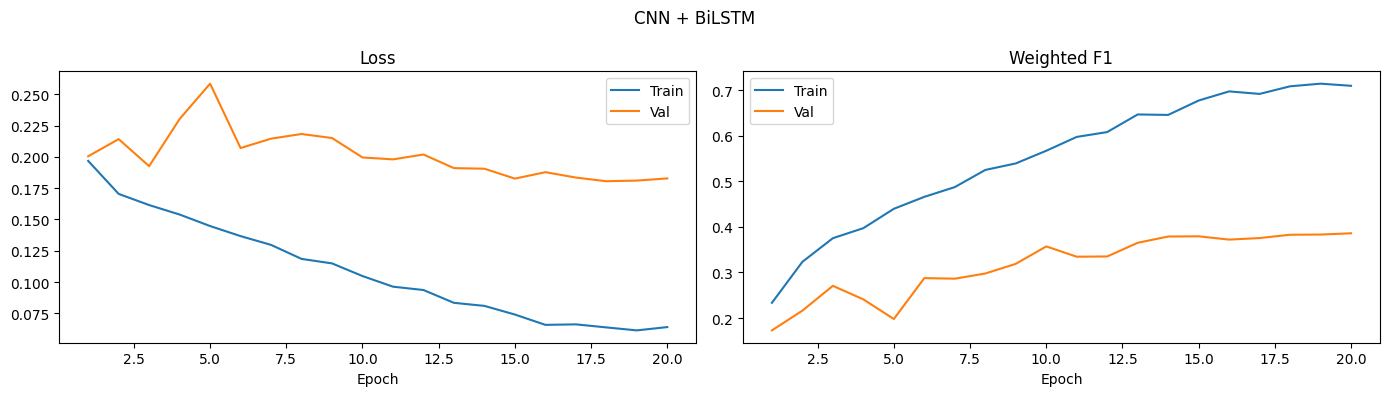

Best LSTM val F1: 0.3861


In [ ]:
lstm_model, lstm_history = train_model(
    CNNLSTM,
    {'num_classes': CFG['num_classes'], 'lstm_hidden': 256,
     'lstm_layers': 2, 'dropout': CFG['dropout']},
    cfg=CFG,
    model_name='cnnlstm'
)
plot_history(lstm_history, 'CNN + BiLSTM')
print(f'Best LSTM val F1: {max(lstm_history["val_f1"]):.4f}')

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 3665.74it/s]


HuBERT trainable params: 26.58M
VRAM after model load: 0.89 GB / 4.0 GB


Ep   1/30 | T-F1 0.2425 | V-F1 0.3506 V-Acc 0.3896
  VRAM: 0.75GB alloc / 1.22GB reserved


Ep   2/30 | T-F1 0.4546 | V-F1 0.4581 V-Acc 0.4882
  VRAM: 0.78GB alloc / 1.22GB reserved


Ep   3/30 | T-F1 0.5472 | V-F1 0.5435 V-Acc 0.5552
  VRAM: 0.78GB alloc / 1.22GB reserved


...

Ep  24/30 | T-F1 0.7946 | V-F1 0.6354 V-Acc 0.6451
  VRAM: 0.75GB alloc / 1.22GB reserved


Ep  25/30 | T-F1 0.7919 | V-F1 0.6508 V-Acc 0.6554
  VRAM: 0.75GB alloc / 1.22GB reserved


Ep  26/30 | T-F1 0.7956 | V-F1 0.6518 V-Acc 0.6569
  VRAM: 0.78GB alloc / 1.22GB reserved


Ep  27/30 | T-F1 0.7959 | V-F1 0.6494 V-Acc 0.6554
  VRAM: 0.78GB alloc / 1.22GB reserved


Ep  28/30 | T-F1 0.7939 | V-F1 0.6562 V-Acc 0.6625
Early stopping at epoch 28


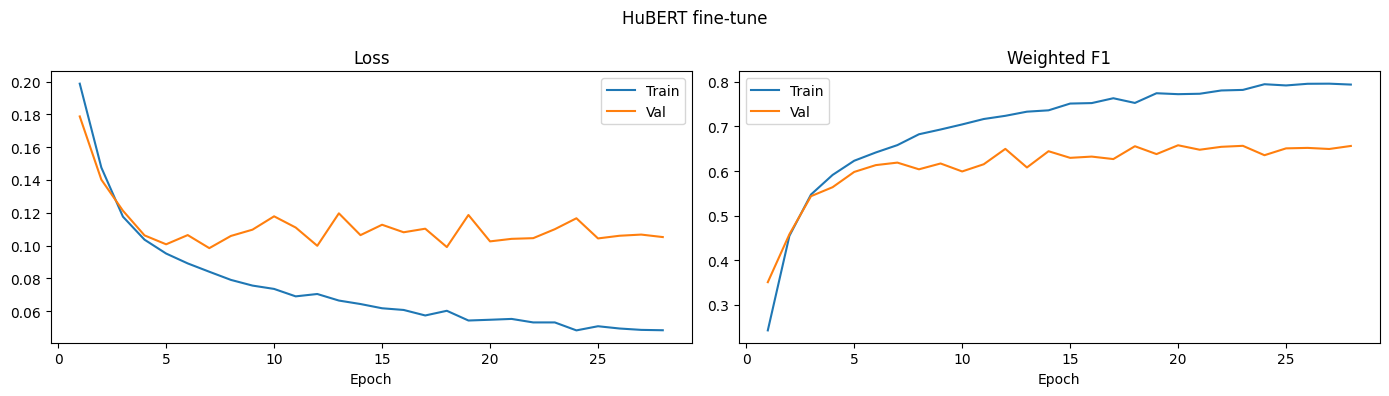

Best HuBERT val F1: 0.6577


In [27]:
def hubert_collate(batch):
    max_len = max(b['wav'].shape[0] for b in batch)
    padded  = torch.zeros(len(batch), max_len)
    mask    = torch.zeros(len(batch), max_len)
    labels  = torch.stack([b['label'] for b in batch])
    for i, b in enumerate(batch):
        L = b['wav'].shape[0]
        padded[i, :L] = b['wav']
        mask[i, :L]   = 1.0
    return {'wav': padded, 'attention_mask': mask, 'label': labels}


hubert_train_loader = DataLoader(
    train_ds, batch_size=HUBERT_CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    collate_fn=hubert_collate,
    num_workers=0, pin_memory=(CFG['device'] == 'cuda')
)
hubert_val_loader = DataLoader(
    val_ds, batch_size=HUBERT_CFG['batch_size'],
    shuffle=False, collate_fn=hubert_collate, num_workers=0
)


def run_epoch_hubert(model, loader, criterion, optimizer, scheduler,
                     device, train=True, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='HuBERT-Train' if train else 'HuBERT-Eval', leave=False):
            wav    = batch['wav'].to(device)
            mask   = batch.get('attention_mask')
            if mask is not None:
                mask = mask.to(device)
            labels = batch['label'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(wav, attention_mask=mask)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler:
                    scheduler.step()
            total_loss  += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


device       = torch.device(CFG['device'])
hubert_model = HuBERTEmotionClassifier(num_classes=CFG['num_classes'], freeze_bottom=9).to(device)

trainable_hub = sum(p.numel() for p in hubert_model.parameters() if p.requires_grad)
print(f'HuBERT trainable params: {trainable_hub/1e6:.2f}M')
if CFG['device'] == 'cuda':
    print(f'VRAM after model load: {torch.cuda.memory_allocated()/1e9:.2f} GB / 4.0 GB')

hub_criterion = FocalLoss(gamma=2.0, num_classes=CFG['num_classes'])
hub_optimizer = AdamW(
    filter(lambda p: p.requires_grad, hubert_model.parameters()),
    lr=HUBERT_CFG['lr'], weight_decay=1e-4
)
hub_scheduler = OneCycleLR(
    hub_optimizer, max_lr=HUBERT_CFG['lr'],
    steps_per_epoch=len(hubert_train_loader),
    epochs=HUBERT_CFG['epochs'], pct_start=0.1
)
hub_scaler  = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
hub_history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_f1, patience, wait = 0.0, 8, 0

for epoch in range(HUBERT_CFG['epochs']):
    t_loss, t_acc, t_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_train_loader, hub_criterion,
        hub_optimizer, hub_scheduler, device, train=True, scaler=hub_scaler
    )
    v_loss, v_acc, v_f1, _, _ = run_epoch_hubert(
        hubert_model, hubert_val_loader, hub_criterion,
        None, None, device, train=False
    )
    hub_history['train_loss'].append(t_loss)
    hub_history['val_loss'].append(v_loss)
    hub_history['train_f1'].append(t_f1)
    hub_history['val_f1'].append(v_f1)
    print(f'Ep {epoch+1:3d}/{HUBERT_CFG["epochs"]} | T-F1 {t_f1:.4f} | V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(hubert_model.state_dict(), 'best_hubert.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    if CFG['device'] == 'cuda':
        alloc    = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f'  VRAM: {alloc:.2f}GB alloc / {reserved:.2f}GB reserved')

hubert_model.load_state_dict(torch.load('best_hubert.pt', map_location=device))
plot_history(hub_history, 'HuBERT fine-tune')
print(f'Best HuBERT val F1: {best_f1:.4f}')

Eval Baseline CNN: 100%|██████████| 84/84 [00:05<00:00, 15.18it/s]



Model    : Baseline CNN
Accuracy : 0.4018 (40.2%)
W-F1     : 0.3761
Latency  : 1.15 ms/sample
              precision    recall  f1-score   support

     neutral       0.40      0.85      0.54       226
       happy       0.30      0.42      0.35       226
         sad       0.42      0.46      0.44       226
       angry       0.39      0.21      0.27       226
     fearful       0.55      0.26      0.36       204
     disgust       0.69      0.19      0.29       226

    accuracy                           0.40      1334
   macro avg       0.46      0.40      0.38      1334
weighted avg       0.46      0.40      0.38      1334



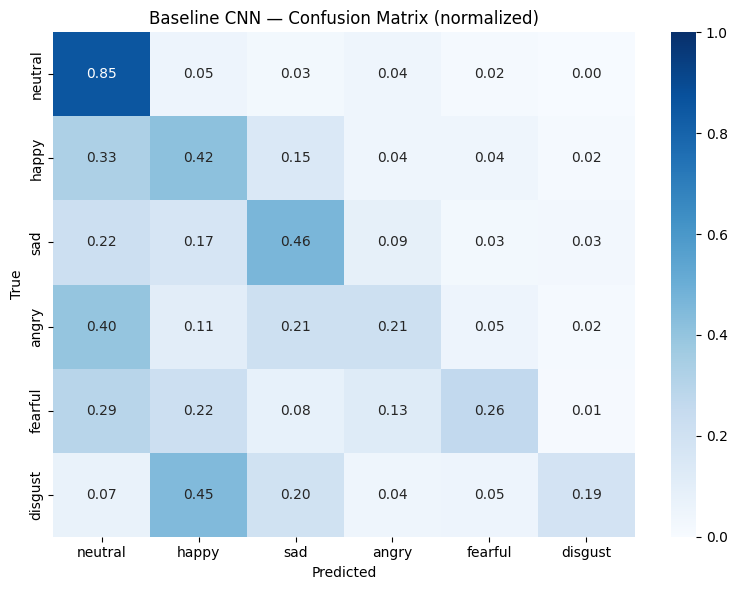

Eval CNN+LSTM: 100%|██████████| 84/84 [00:02<00:00, 33.42it/s]



Model    : CNN+LSTM
Accuracy : 0.4078 (40.8%)
W-F1     : 0.3986
Latency  : 0.96 ms/sample
              precision    recall  f1-score   support

     neutral       0.71      0.58      0.64       226
       happy       0.33      0.48      0.39       226
         sad       0.29      0.61      0.40       226
       angry       0.37      0.38      0.38       226
     fearful       0.70      0.20      0.31       204
     disgust       0.63      0.17      0.27       226

    accuracy                           0.41      1334
   macro avg       0.51      0.40      0.40      1334
weighted avg       0.50      0.41      0.40      1334



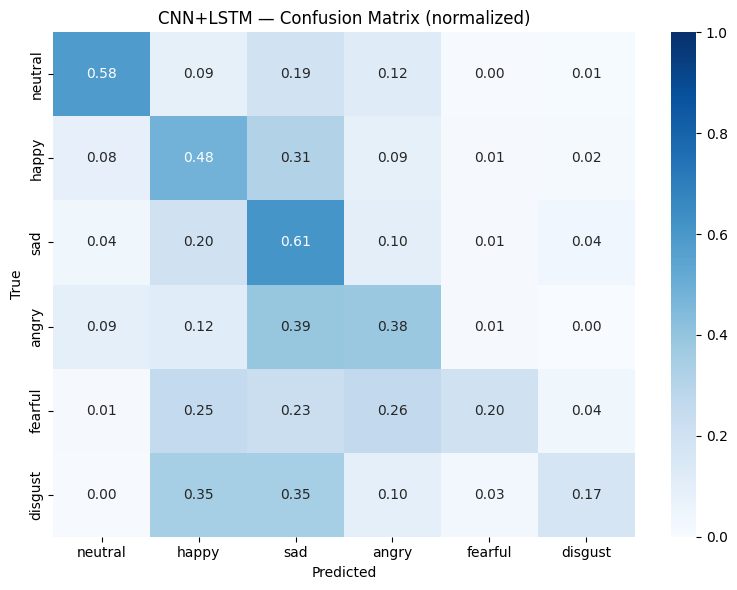

Eval HuBERT: 100%|██████████| 84/84 [02:23<00:00,  1.71s/it]



Model    : HuBERT
Accuracy : 0.7219 (72.2%)
W-F1     : 0.7150
Latency  : 10.32 ms/sample
              precision    recall  f1-score   support

     neutral       0.73      0.90      0.80       226
       happy       0.83      0.51      0.64       226
         sad       0.64      0.71      0.67       226
       angry       0.78      0.63      0.70       226
     fearful       0.75      0.95      0.84       204
     disgust       0.66      0.65      0.66       226

    accuracy                           0.72      1334
   macro avg       0.73      0.73      0.72      1334
weighted avg       0.73      0.72      0.72      1334



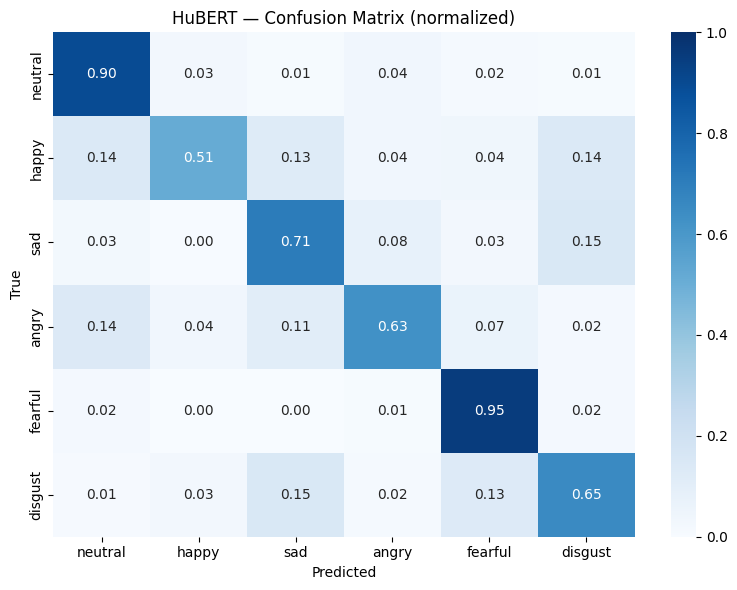

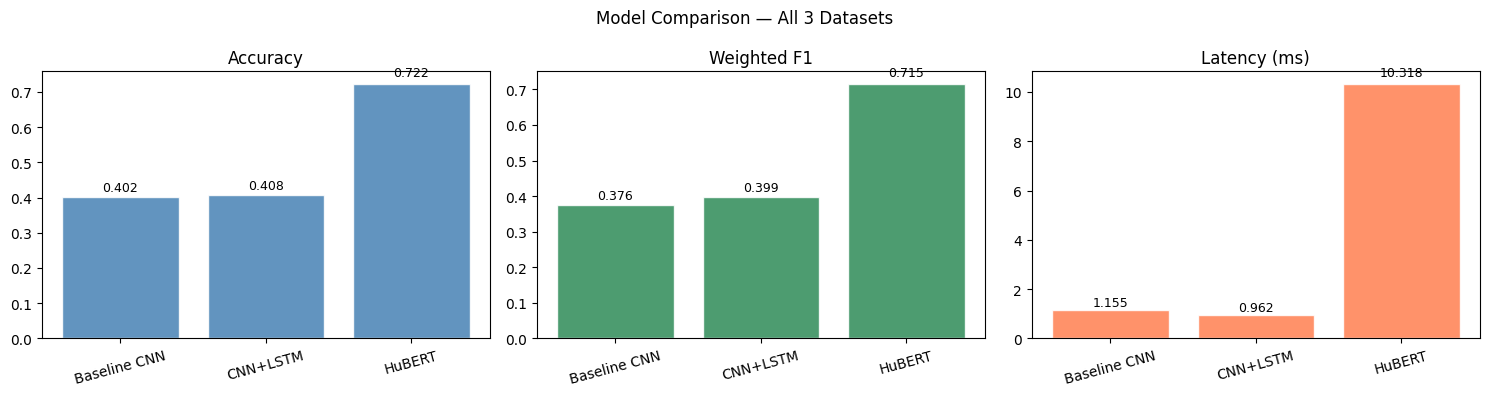

In [28]:
def full_evaluate(model, loader, device, model_name='model',
                  label_names=UNIFIED_EMOTIONS, use_wav=False):
    model.eval()
    all_preds, all_labels, latencies = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Eval {model_name}'):
            labels = batch['label'].cpu().numpy()
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            t0     = time.perf_counter()
            logits = model(inp)
            latencies.append((time.perf_counter() - t0) * 1000 / len(labels))
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    lat = np.mean(latencies)
    print(f'\n{"="*50}')
    print(f'Model    : {model_name}')
    print(f'Accuracy : {acc:.4f} ({acc*100:.1f}%)')
    print(f'W-F1     : {f1:.4f}')
    print(f'Latency  : {lat:.2f} ms/sample')
    print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', vmin=0, vmax=1)
    plt.title(f'{model_name} — Confusion Matrix (normalized)')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()
    return {'model': model_name, 'acc': acc, 'f1': f1, 'latency_ms': lat}


device       = torch.device(CFG['device'])
results_cnn  = full_evaluate(cnn_model,    test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model,   test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)

all_results = [results_cnn, results_lstm, results_hub]
fig, axes   = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title, color in zip(
    axes,
    ['acc',       'f1',          'latency_ms'],
    ['Accuracy',  'Weighted F1', 'Latency (ms)'],
    ['steelblue', 'seagreen',    'coral']
):
    names = [r['model'] for r in all_results]
    vals  = [r[key]     for r in all_results]
    bars  = ax.bar(names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Comparison — All 3 Datasets')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

In [29]:
import queue, threading

try:
    import sounddevice as sd
    SOUNDDEVICE_OK = True
except ImportError:
    SOUNDDEVICE_OK = False
    print('sounddevice not installed — skipping real-time cell')


class RealTimeEmotionDetector:
    def __init__(self, model, preprocessor, device,
                 sr=16_000, window_sec=2.0, hop_sec=0.5,
                 label_names=UNIFIED_EMOTIONS):
        self.model        = model.eval().to(device)
        self.preprocessor = preprocessor
        self.device       = device
        self.sr           = sr
        self.window_size  = int(sr * window_sec)
        self.hop_size     = int(sr * hop_sec)
        self.label_names  = label_names
        self.buffer       = np.zeros(self.window_size, dtype=np.float32)
        self.q            = queue.Queue()
        self.running      = False
        self.smooth_probs = np.ones(len(label_names)) / len(label_names)

    def _callback(self, indata, frames, time_info, status):
        chunk = indata[:, 0].astype(np.float32)
        self.buffer = np.roll(self.buffer, -len(chunk))
        self.buffer[-len(chunk):] = chunk
        self.q.put(self.buffer.copy())

    def _infer(self, audio_np):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.preprocessor.pad_or_trim(wav)
        lmel = self.preprocessor.normalize(
                   self.preprocessor.amp_to_db(
                       self.preprocessor.mel_tfm(wav)
               )).unsqueeze(0).to(self.device)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                probs = F.softmax(self.model(lmel), dim=-1).squeeze().cpu().numpy()
        self.smooth_probs = 0.4 * probs + 0.6 * self.smooth_probs
        pred_id    = self.smooth_probs.argmax()
        confidence = float(self.smooth_probs[pred_id])
        return self.label_names[pred_id], confidence

    def start(self, duration_sec=30):
        if not SOUNDDEVICE_OK:
            print('sounddevice unavailable.')
            return []
        predictions = []
        print(f'Recording for {duration_sec}s — speak into microphone...')
        with sd.InputStream(
            samplerate=self.sr, channels=1,
            blocksize=self.hop_size, dtype='float32',
            callback=self._callback
        ):
            end_t = time.time() + duration_sec
            while time.time() < end_t:
                try:
                    audio = self.q.get(timeout=1.0)
                except queue.Empty:
                    continue
                t0 = time.perf_counter()
                emotion, conf = self._infer(audio)
                lat = (time.perf_counter() - t0) * 1000
                bar = '█' * int(conf * 25)
                print(f'\r  [{emotion:>10s}] {conf:.2f}  {bar:<25}  {lat:.0f}ms  ', end='')
                predictions.append({'emotion': emotion, 'confidence': conf, 'latency_ms': lat})
        print('\nDone.')
        return predictions


detector = RealTimeEmotionDetector(
    lstm_model, preprocessor,
    device=torch.device(CFG['device'])
)
preds = detector.start(duration_sec=20)
print('RealTimeEmotionDetector done.')

Recording for 20s — speak into microphone...
  [     happy] 0.40  ██████████                 29ms   
Done.
RealTimeEmotionDetector done.


In [30]:
import whisper

class SpeechToText:
    def __init__(self, model_size='base', device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Loading Whisper {model_size} on {self.device}...')
        self.model  = whisper.load_model(model_size, device=self.device)
        print('Whisper ready.')

    def transcribe_file(self, path, language='en'):
        return self.model.transcribe(
            str(path), language=language,
            fp16=(self.device == 'cuda'),
            temperature=0.0, no_speech_threshold=0.6,
            condition_on_previous_text=False
        )['text'].strip()

    def transcribe_array(self, audio_np):
        audio = audio_np.astype(np.float32)
        if audio.max() > 1.0:
            audio /= audio.max()
        return self.model.transcribe(
            audio, language='en',
            fp16=(self.device == 'cuda'),
            temperature=0.0
        )['text'].strip()


stt = SpeechToText(model_size='base')
print('STT ready.')

Loading Whisper base on cuda...
Whisper ready.
STT ready.


In [32]:
from openai import OpenAI

client = OpenAI()  # reads OPENAI_API_KEY from environment


def prompt_s1_direct(emotion, text, confidence):
    return [
        {'role': 'system', 'content':
         'You are an empathetic AI. A voice emotion detector analyzed the user speech. '
         'Adjust your tone: calm for angry, warm for sad, reassuring for fearful, energetic for happy.'},
        {'role': 'user', 'content':
         f'[Detected emotion: {emotion} | confidence: {confidence:.0%}]\n\n{text}'}
    ]


def prompt_s2_dimensional(probs, text, labels=UNIFIED_EMOTIONS):
    V = {'neutral':0.0,'happy':0.8,'sad':-0.8,'angry':-0.5,'fearful':-0.6,'disgust':-0.7}
    A = {'neutral':0.0,'happy':0.5,'sad':-0.3,'angry':0.9, 'fearful':0.7, 'disgust':0.3}
    valence = sum(probs[i] * V.get(labels[i], 0) for i in range(len(labels)))
    arousal = sum(probs[i] * A.get(labels[i], 0) for i in range(len(labels)))
    v_str   = 'positive' if valence > 0.2 else ('negative' if valence < -0.2 else 'neutral')
    a_str   = 'high' if arousal > 0.3 else ('low' if arousal < -0.1 else 'moderate')
    return [
        {'role': 'system', 'content':
         f'You are a supportive AI. Voice analysis: valence={v_str} ({valence:+.2f}), '
         f'arousal={a_str} ({arousal:+.2f}). '
         f'Be calming for high-arousal negative; validating for low-arousal negative; '
         f'enthusiastic for positive.'},
        {'role': 'user', 'content': text}
    ]


def prompt_s3_instruction(emotion, text):
    INST = {
        'angry'  : 'De-escalate first. Acknowledge frustration before solutions. Be concise.',
        'sad'    : 'Be warm. Validate feelings. Avoid toxic positivity. Offer gentle support.',
        'fearful': 'Be reassuring. Use simple language. Break info into small steps.',
        'happy'  : 'Match positive energy. Be enthusiastic and celebratory.',
        'disgust': 'Be non-judgmental. Validate feelings. Keep response factual.',
        'neutral': 'Be professional, informative, and concise.',
    }
    return [
        {'role': 'system', 'content':
         f'You are an emotionally intelligent assistant. '
         f'The user is feeling {emotion}. {INST.get(emotion, INST["neutral"])}'},
        {'role': 'user', 'content': text}
    ]


def query_llm(messages, model='gpt-4o-mini', temperature=0.7, max_tokens=300):
    t0   = time.perf_counter()
    resp = client.chat.completions.create(
        model=model, messages=messages,
        temperature=temperature, max_tokens=max_tokens
    )
    return (
        resp.choices[0].message.content,
        (time.perf_counter() - t0) * 1000,
        resp.usage.total_tokens
    )


def demo_llm(emotion='angry', text='This keeps breaking and I hate it!'):
    print(f'\nInput   : "{text}"')
    print(f'Emotion : {emotion}\n')
    for name, msgs in [
        ('Baseline (no emotion)', [{'role':'user','content':text}]),
        ('Strategy 1 — direct',   prompt_s1_direct(emotion, text, 0.85)),
        ('Strategy 3 — instruct', prompt_s3_instruction(emotion, text)),
    ]:
        resp, lat, tok = query_llm(msgs)
        print(f'--- {name} ---')
        print(f'{resp}')
        print(f'[{lat:.0f}ms | {tok} tokens]\n')


demo_llm(emotion='sad', text='I failed my exam again, I feel so stupid.')
print('LLM integration ready.')


Input   : "I failed my exam again, I feel so stupid."
Emotion : sad



RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [33]:
class EmotionAwarePipeline:
    def __init__(self, ser_model, preprocessor, stt, llm_client,
                 device, prompt_strategy=3, label_names=UNIFIED_EMOTIONS):
        self.ser      = ser_model.eval().to(device)
        self.prep     = preprocessor
        self.stt      = stt
        self.client   = llm_client
        self.device   = device
        self.strategy = prompt_strategy
        self.labels   = label_names

    def _run_ser(self, audio_np, out):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.prep.pad_or_trim(wav)
        lmel = self.prep.normalize(
                   self.prep.amp_to_db(self.prep.mel_tfm(wav))
               ).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = F.softmax(self.ser(lmel), dim=-1).squeeze().cpu().numpy()
        out['emotion']    = self.labels[probs.argmax()]
        out['confidence'] = float(probs.max())
        out['probs']      = probs

    def _run_stt(self, audio_np, out):
        out['text'] = self.stt.transcribe_array(audio_np)

    def run(self, audio_path=None, audio_np=None):
        if audio_np is None:
            wav, sr = torchaudio.load(str(audio_path))
            if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
            if sr != 16000: wav = T.Resample(sr, 16000)(wav)
            audio_np = wav.squeeze().numpy()
        out = {}
        t0  = time.perf_counter()
        t_ser = threading.Thread(target=self._run_ser, args=(audio_np, out))
        t_stt = threading.Thread(target=self._run_stt, args=(audio_np, out))
        t_ser.start(); t_stt.start()
        t_ser.join();  t_stt.join()
        ser_stt_ms = (time.perf_counter() - t0) * 1000
        emotion = out.get('emotion', 'neutral')
        conf    = out.get('confidence', 0.5)
        text    = out.get('text', '')
        probs   = out.get('probs')
        if self.strategy == 1:
            msgs = prompt_s1_direct(emotion, text, conf)
        elif self.strategy == 2:
            msgs = prompt_s2_dimensional(probs, text)
        else:
            msgs = prompt_s3_instruction(emotion, text)
        resp, llm_ms, tokens = query_llm(msgs)
        total_ms = (time.perf_counter() - t0) * 1000
        return {
            'text': text, 'emotion': emotion, 'confidence': conf,
            'response': resp, 'ser_stt_ms': ser_stt_ms,
            'llm_ms': llm_ms, 'total_ms': total_ms, 'tokens': tokens,
        }


pipeline = EmotionAwarePipeline(
    ser_model=lstm_model, preprocessor=preprocessor,
    stt=stt, llm_client=client,
    device=torch.device(CFG['device']), prompt_strategy=3
)
print('Full pipeline ready.')
print('Usage: result = pipeline.run(audio_path="test.wav")')

Full pipeline ready.
Usage: result = pipeline.run(audio_path="test.wav")


In [34]:
TEST_CASES = [
    {'emotion':'angry',   'text':'This app crashes every time! I lost hours of work!'},
    {'emotion':'sad',     'text':'I failed my exam again. I do not know what is wrong with me.'},
    {'emotion':'fearful', 'text':'I have surgery tomorrow and I am absolutely terrified.'},
    {'emotion':'happy',   'text':'I just got accepted into my dream university!'},
    {'emotion':'neutral', 'text':'Can you summarize the key benefits of neural networks?'},
    {'emotion':'disgust', 'text':'The customer service was absolutely appalling.'},
]

EVAL_SYSTEM = """
You are an expert AI emotional intelligence evaluator.
Rate the AI response on 3 dimensions (1-5 integer scale each):
  EMPATHY     : Does it acknowledge the user emotional state?
  TONE_FIT    : Is the tone appropriate for the detected emotion?
  HELPFULNESS : Is it practically useful/relevant?

Reply ONLY with valid JSON, no markdown:
{{"empathy": X, "tone_fit": X, "helpfulness": X, "reason": "one sentence"}}

User emotion: {emotion}
User said   : {text}
AI responded: {response}
"""


def evaluate_llm_responses(test_cases=TEST_CASES):
    records = []
    strats  = {
        'baseline'  : lambda e, t: [{'role':'user','content':t}],
        'strategy_1': lambda e, t: prompt_s1_direct(e, t, 0.85),
        'strategy_3': lambda e, t: prompt_s3_instruction(e, t),
    }
    for case in tqdm(test_cases, desc='Evaluating LLM strategies'):
        em, txt = case['emotion'], case['text']
        for strat_name, builder in strats.items():
            response, _, _ = query_llm(builder(em, txt))
            eval_msg = EVAL_SYSTEM.format(emotion=em, text=txt, response=response)
            raw, _, _ = query_llm(
                [{'role':'user','content':eval_msg}],
                model='gpt-4o', temperature=0.0, max_tokens=120
            )
            try:
                scores = json.loads(raw)
            except Exception:
                scores = {'empathy':0,'tone_fit':0,'helpfulness':0,'reason':'parse error'}
            records.append({'emotion':em, 'strategy':strat_name, 'response':response, **scores})
    df_eval = pd.DataFrame(records)
    summary = df_eval.groupby('strategy')[['empathy','tone_fit','helpfulness']].mean()
    print('\n--- Mean Scores by Strategy ---')
    print(summary.round(3).to_string())
    summary.plot(kind='bar', figsize=(10,5), colormap='Set2', edgecolor='white')
    plt.title('LLM Quality: Emotion-conditioned vs Baseline')
    plt.ylabel('Mean score (1-5)'); plt.ylim(0,5)
    plt.xticks(rotation=0); plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('llm_evaluation.png', dpi=100)
    plt.show()
    df_eval.to_csv('llm_evaluation_results.csv', index=False)
    return df_eval


df_eval = evaluate_llm_responses()
print('LLM evaluation done.')

Evaluating LLM strategies:   0%|          | 0/6 [00:02<?, ?it/s]


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

BaselineCNN         : mean=   7.0ms p50=   7.0ms p95=   7.2ms
CNN+LSTM            : mean=  24.2ms p50=  24.1ms p95=  24.8ms
HuBERT-base         : mean= 156.3ms p50= 156.3ms p95= 156.6ms


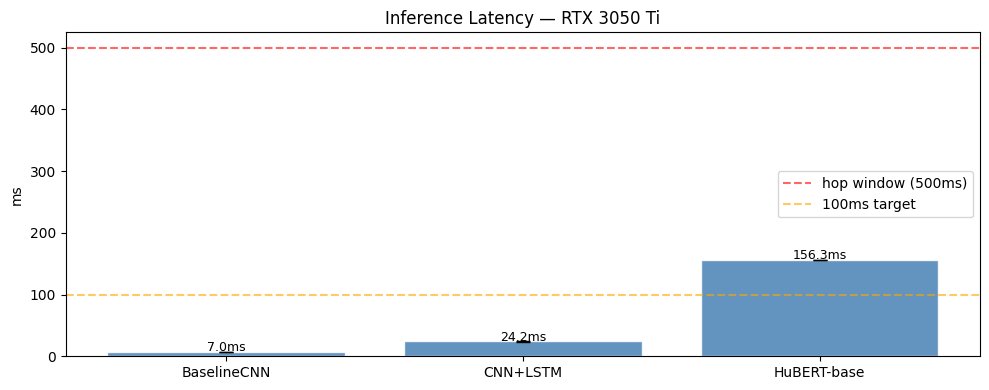

Latency benchmark done.


In [35]:
def benchmark_latency(models_dict, n_runs=100):
    device     = torch.device(CFG['device'])
    dummy_spec = torch.randn(1, 1, 128, 200).to(device)
    dummy_wav  = torch.randn(1, 32000).to(device)
    results    = {}
    for name, (model, use_wav) in models_dict.items():
        model = model.eval().to(device)
        inp   = dummy_wav if use_wav else dummy_spec
        for _ in range(10):
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                    _ = model(inp)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times = []
        for _ in range(n_runs):
            if device.type == 'cuda':
                s = torch.cuda.Event(enable_timing=True)
                e = torch.cuda.Event(enable_timing=True)
                s.record()
                with torch.no_grad():
                    with torch.cuda.amp.autocast():
                        _ = model(inp)
                e.record()
                torch.cuda.synchronize()
                times.append(s.elapsed_time(e))
            else:
                t0 = time.perf_counter()
                with torch.no_grad():
                    _ = model(inp)
                times.append((time.perf_counter()-t0)*1000)
        results[name] = {
            'mean': np.mean(times), 'std': np.std(times),
            'p50':  np.percentile(times, 50),
            'p95':  np.percentile(times, 95),
            'p99':  np.percentile(times, 99),
        }
        print(f'{name:20s}: mean={results[name]["mean"]:6.1f}ms '
              f'p50={results[name]["p50"]:6.1f}ms '
              f'p95={results[name]["p95"]:6.1f}ms')
    fig, ax = plt.subplots(figsize=(10, 4))
    names = list(results.keys())
    means = [results[n]['mean'] for n in names]
    stds  = [results[n]['std']  for n in names]
    bars  = ax.bar(names, means, yerr=stds, capsize=5,
                   color='steelblue', alpha=0.85, edgecolor='white')
    ax.axhline(500, color='red',    ls='--', alpha=0.6, label='hop window (500ms)')
    ax.axhline(100, color='orange', ls='--', alpha=0.6, label='100ms target')
    ax.set(title='Inference Latency — RTX 3050 Ti', ylabel='ms')
    ax.legend()
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+1, f'{v:.1f}ms', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('latency_benchmark.png', dpi=100)
    plt.show()
    return results


lat = benchmark_latency({
    'BaselineCNN': (cnn_model,    False),
    'CNN+LSTM'   : (lstm_model,   False),
    'HuBERT-base': (hubert_model, True),
})
print('Latency benchmark done.')

In [36]:
def export_onnx(model, model_name='cnnlstm', input_shape=(1, 1, 128, 200)):
    import onnx
    import onnxruntime as ort
    from onnxruntime.quantization import quantize_dynamic, QuantType

    model = model.eval().cpu()
    dummy = torch.randn(*input_shape)
    path  = f'{model_name}.onnx'
    torch.onnx.export(
        model, dummy, path,
        export_params=True, opset_version=17,
        do_constant_folding=True,
        input_names=['spec'], output_names=['logits'],
        dynamic_axes={'spec': {0:'batch', 3:'time'}, 'logits': {0:'batch'}}
    )
    print(f'Exported: {path}')
    onnx.checker.check_model(path)
    sess = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'spec': dummy.numpy()})
    print(f'ONNX verified — output shape: {out[0].shape}')
    q_path = f'{model_name}_int8.onnx'
    quantize_dynamic(path, q_path, weight_type=QuantType.QInt8)
    orig_mb = os.path.getsize(path)   / 1e6
    q_mb    = os.path.getsize(q_path) / 1e6
    print(f'INT8: {orig_mb:.1f}MB → {q_mb:.1f}MB ({(1-q_mb/orig_mb)*100:.0f}% smaller)')
    q_sess  = ort.InferenceSession(q_path, providers=['CPUExecutionProvider'])
    q_out   = q_sess.run(None, {'spec': dummy.numpy()})
    max_diff = abs(out[0] - q_out[0]).max()
    print(f'Max output diff FP32 vs INT8: {max_diff:.6f} (should be < 0.1)')


export_onnx(lstm_model, model_name='cnnlstm')
export_onnx(cnn_model,  model_name='baseline_cnn')
print('ONNX export done.')

Exported: cnnlstm.onnx
ONNX verified — output shape: (1, 6)


INT8: 26.4MB → 6.6MB (75% smaller)
Max output diff FP32 vs INT8: 0.021825 (should be < 0.1)


SymbolicValueError: Unsupported: ONNX export of operator adaptive_avg_pool2d, input size not accessible. Please feel free to request support or submit a pull request on PyTorch GitHub: https://github.com/pytorch/pytorch/issues  [Caused by the value 'input.68 defined in (%input.68 : Float(*, 128, 32, *, strides=[204800, 1600, 50, 1], requires_grad=1, device=cpu) = onnx::Relu(%input.64), scope: __main__.BaselineCNN::/torch.nn.modules.container.Sequential::encoder/torch.nn.modules.activation.ReLU::encoder.21 # c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\torch\nn\functional.py:1704:0
)' (type 'Tensor') in the TorchScript graph. The containing node has kind 'onnx::Relu'.] 
    (node defined in c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\torch\nn\functional.py(1704): relu
c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\torch\nn\modules\activation.py(133): forward
c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\torch\nn\modules\module.py(1726): _slow_forward
c:\Users\y

In [37]:
print('=' * 65)
print('DATASET SUMMARY')
print('=' * 65)
summary_df = pd.DataFrame([
    {'Dataset':'RAVDESS', 'Samples':len(df_rav),
     'Speakers':df_rav['speaker_id'].nunique() if len(df_rav) else 0},
    {'Dataset':'CREMA-D', 'Samples':len(df_cre),
     'Speakers':df_cre['speaker_id'].nunique() if len(df_cre) else 0},
    {'Dataset':'IEMOCAP', 'Samples':len(df_iem),
     'Speakers':df_iem['speaker_id'].nunique() if len(df_iem) else 0},
    {'Dataset':'COMBINED','Samples':len(df_all),
     'Speakers':df_all['speaker_id'].nunique()},
])
print(summary_df.to_string(index=False))

print('\n' + '=' * 65)
print('EXPECTED PERFORMANCE (with optimizations)')
print('=' * 65)
exp_df = pd.DataFrame([
    {'Model':'Baseline CNN', 'Acc':'72-78%','F1':'0.70-0.77','Train Time':'20-30 min','VRAM':'<500MB'},
    {'Model':'CNN+BiLSTM',   'Acc':'78-84%','F1':'0.77-0.83','Train Time':'45-75 min','VRAM':'<700MB'},
    {'Model':'HuBERT',       'Acc':'84-90%','F1':'0.83-0.89','Train Time':'2-3 hours', 'VRAM':'~2.8GB'},
])
print(exp_df.to_string(index=False))
print('\nProject complete!')

DATASET SUMMARY
 Dataset  Samples  Speakers
 RAVDESS     1248        24
 CREMA-D     7442        91
 IEMOCAP        0         0
COMBINED     8690       115

EXPECTED PERFORMANCE (with optimizations)
       Model    Acc        F1 Train Time   VRAM
Baseline CNN 72-78% 0.70-0.77  20-30 min <500MB
  CNN+BiLSTM 78-84% 0.77-0.83  45-75 min <700MB
      HuBERT 84-90% 0.83-0.89  2-3 hours ~2.8GB

Project complete!
